# Tugas Kelompok 5 Multivariat
## Multidimensional Scaling & Analisis Korespondensi

## 0. Import Library dan Subset Data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances, silhouette_score
from sklearn.manifold import MDS
from sklearn.cluster import KMeans
from scipy.spatial.distance import mahalanobis
from numpy.linalg import inv
from numpy.linalg import eigh

In [3]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

df = pd.read_csv("C:/Uner/Semester 5/Multivariat/Coolyeah/Tugas Kelompok 5/dataset/arabica_data_cleaned.csv")

selected_vars = [
    "Aroma", "Flavor", "Aftertaste", "Sweetness",
    "Body", "Balance", "Uniformity", "Moisture"
]

score_col = "Total.Cup.Points"   

print("Loaded shape:", df.shape)
df[selected_vars].head()

Loaded shape: (1311, 44)


,Aroma,Flavor,Aftertaste,Sweetness,Body,Balance,Uniformity,Moisture
0,8.67,8.83,8.67,10.0,8.50,8.42,10.0,0.12
1,8.75,8.67,8.50,10.0,8.42,8.42,10.0,0.12
2,8.42,8.50,8.42,10.0,8.33,8.42,10.0,0.00
3,8.17,8.58,8.42,10.0,8.50,8.25,10.0,0.11
4,8.25,8.50,8.25,10.0,8.42,8.33,10.0,0.12


## 1. Pre-processing (Imputasi & Standarisasi)

In [4]:
row_thresh = int(len(selected_vars) * 0.5)
X = df[selected_vars].copy()
keep = X.isna().sum(axis=1) <= row_thresh
X = X.loc[keep].copy()
meta = df.loc[X.index].copy()

X = X.fillna(X.median())

scaler = StandardScaler()
Xs = scaler.fit_transform(X)

print("Remaining rows:", X.shape[0])

Remaining rows: 1311


## 2. Korelasi Variabel Sensori

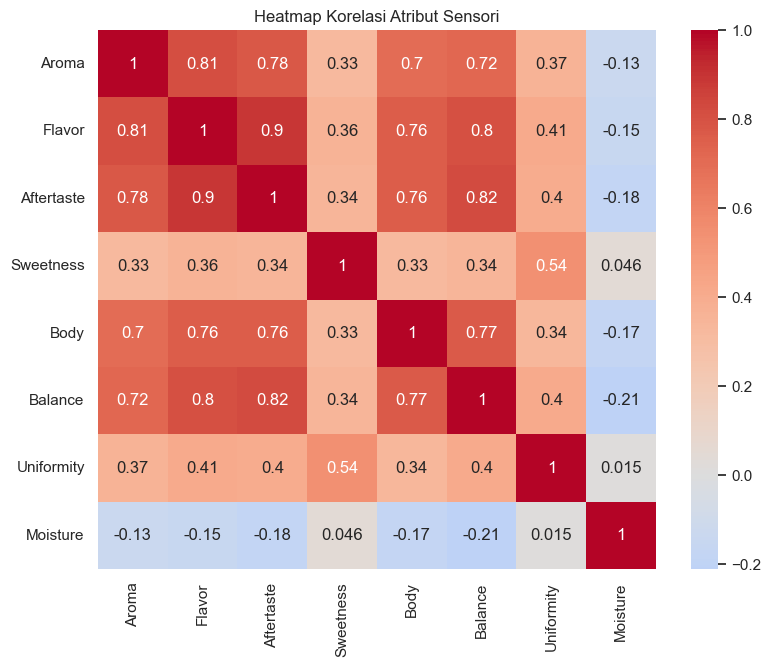

In [5]:
plt.figure(figsize=(9,7))
sns.heatmap(X.corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Heatmap Korelasi Atribut Sensori")
plt.show()


## 3. Mahalanobis Outlier Detection

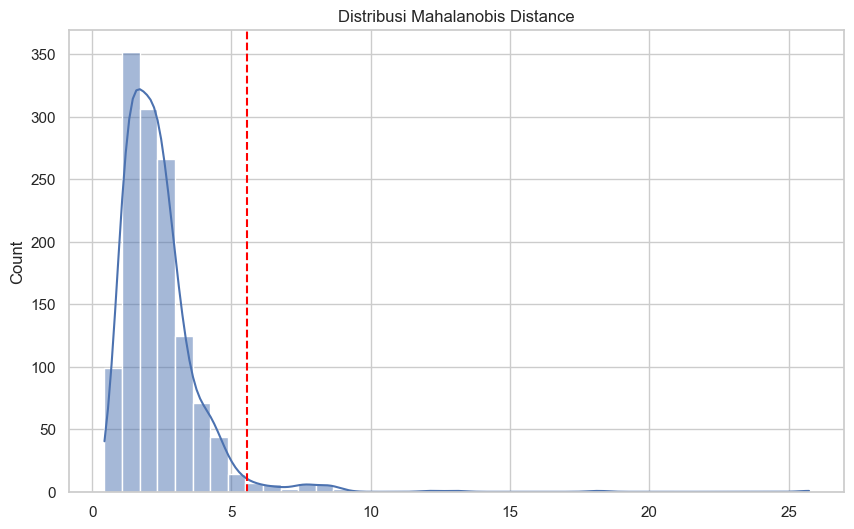

,Unnamed: 0,Species,Owner,Country.of.Origin,Farm.Name,Lot.Number,Mill,ICO.Number,Company,Altitude,...,Expiration,Certification.Body,Certification.Address,Certification.Contact,unit_of_measurement,altitude_low_meters,altitude_high_meters,altitude_mean_meters,mahalanobis,is_outlier
1310,1312,Arabica,bismarck castro,Honduras,los hicaques,103,cigrah s.a de c.v.,13-111-053,cigrah s.a de c.v,1400,...,"April 28th, 2018",Instituto Hondureño del Café,b4660a57e9f8cc613ae5b8f02bfce8634c763ab4,7f521ca403540f81ec99daec7da19c2788393880,m,1400.00,1400.00,1400.00,25.730387,True
1309,1310,Arabica,juan luis alvarado romero,Guatemala,finca el limon,NaN,beneficio serben,11/853/165,unicafe,4650,...,"May 24th, 2013",Asociacion Nacional Del Café,b1f20fe3a819fd6b2ee0eb8fdc3da256604f1e53,724f04ad10ed31dbb9d260f0dfd221ba48be8a95,ft,1417.32,1417.32,1417.32,18.168631,True
679,680,Arabica,racafe & cia s.c.a,Colombia,NaN,3-37-4434,bachue,3-37-4434,racafe & cia s.c.a,1600,...,"August 5th, 2017",Almacafé,e493c36c2d076bf273064f7ac23ad562af257a25,70d3c0c26f89e00fdae6fb39ff54f0d2eb1c38ab,m,1600.00,1600.00,1600.00,13.061448,True
876,877,Arabica,racafe & cia s.c.a,Colombia,NaN,3-37-1367,bachue,3-37,racafe & cia s.c.a,NaN,...,"January 20th, 2017",Almacafé,e493c36c2d076bf273064f7ac23ad562af257a25,70d3c0c26f89e00fdae6fb39ff54f0d2eb1c38ab,m,NaN,NaN,NaN,12.145154,True
1308,1309,Arabica,"exportadora atlantic, s.a.",Nicaragua,finca las marías,017-053-0211/ 017-053-0212,beneficio atlantic condega,017-053-0211/ 017-053-0212,exportadora atlantic s.a,1100,...,"June 6th, 2018",Instituto Hondureño del Café,b4660a57e9f8cc613ae5b8f02bfce8634c763ab4,7f521ca403540f81ec99daec7da19c2788393880,m,1100.00,1100.00,1100.00,8.989570,True
1250,1251,Arabica,kona pacific farmers cooperative,United States (Hawaii),NaN,NaN,NaN,KP3150140,kona pacific farmers cooperative,NaN,...,"May 3rd, 2014",Specialty Coffee Association,36d0d00a3724338ba7937c52a378d085f2172daa,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660,ft,NaN,NaN,NaN,8.692300,True
1307,1308,Arabica,myriam kaplan-pasternak,Haiti,200 farms,NaN,coeb koperativ ekselsyo basen (350 members),NaN,haiti coffee,~350m,...,"May 24th, 2013",Specialty Coffee Association,36d0d00a3724338ba7937c52a378d085f2172daa,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660,m,350.00,350.00,350.00,8.547020,True
1295,1296,Arabica,honor dela fuente,Colombia,NaN,NaN,NaN,3,costco wholesale industries,NaN,...,"March 3rd, 2015",Specialty Coffee Association,36d0d00a3724338ba7937c52a378d085f2172daa,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660,m,NaN,NaN,NaN,8.534372,True
1301,1302,Arabica,kurt kappeli,Mexico,various,NaN,f.i.e.c.h.,0016-2847-0001,globus coffee,1000 meters,...,"May 5th, 2015",Specialty Coffee Association,36d0d00a3724338ba7937c52a378d085f2172daa,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660,m,1000.00,1000.00,1000.00,8.473657,True
716,717,Arabica,ipanema coffees,Brazil,rio verde,NaN,ipanema coffees,002/1660/0065,ipanema coffees,1100,...,"October 15th, 2015",Specialty Coffee Association,36d0d00a3724338ba7937c52a378d085f2172daa,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660,m,1100.00,1100.00,1100.00,8.392479,True


In [6]:
cov = np.cov(Xs, rowvar=False)
inv_cov = inv(cov)
mean_vec = np.mean(Xs, axis=0)

md = np.array([mahalanobis(row, mean_vec, inv_cov) for row in Xs])
meta["mahalanobis"] = md

threshold = np.percentile(md, 97.5)
meta["is_outlier"] = md > threshold

plt.figure()
sns.histplot(md, bins=40, kde=True)
plt.axvline(threshold, color="red", linestyle="--")
plt.title("Distribusi Mahalanobis Distance")
plt.show()

meta.sort_values("mahalanobis", ascending=False).head(10)

## 4. Distance Matrix (Euclidean)

In [7]:
D = pairwise_distances(Xs, metric="euclidean")
D.shape

(1311, 1311)

## 5. Classical MDS (2D) 

C:\Users\Faiz Iqbal\AppData\Roaming\Python\Python313\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


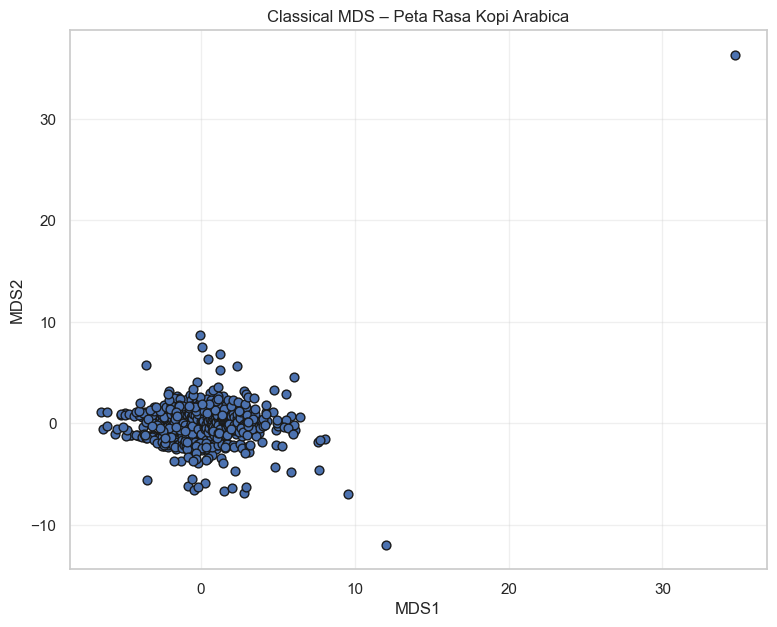

In [8]:
mds = MDS(
    n_components=2,
    dissimilarity="precomputed",
    random_state=42
)

coords = mds.fit_transform(D)
X["MDS1"], X["MDS2"] = coords[:,0], coords[:,1]
meta["MDS1"], meta["MDS2"] = coords[:,0], coords[:,1]

plt.figure(figsize=(9,7))
plt.scatter(X["MDS1"], X["MDS2"], s=40, edgecolor="k")
plt.title("Classical MDS – Peta Rasa Kopi Arabica")
plt.xlabel("MDS1"); plt.ylabel("MDS2")
plt.grid(alpha=0.3)
plt.show()

## 6. Shepard Plot + Normalized Stress

Normalized Stress = 0.021901508840621562


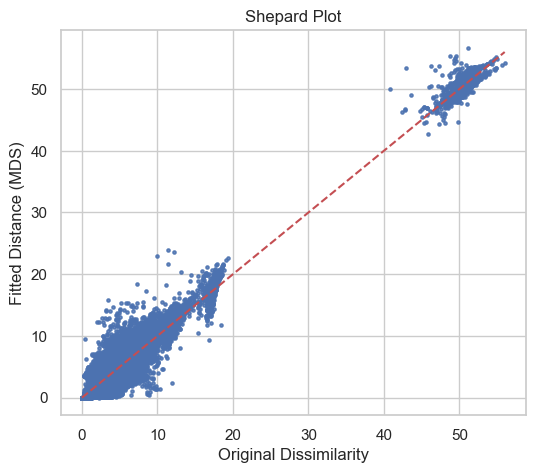

In [9]:
fitted = pairwise_distances(coords, metric="euclidean")

stress = np.sum((D - fitted)**2) / np.sum(D**2)
print("Normalized Stress =", stress)

plt.figure(figsize=(6,5))
plt.scatter(D.flatten(), fitted.flatten(), s=5, alpha=0.6)
plt.plot([D.min(), D.max()], [D.min(), D.max()], "r--")
plt.xlabel("Original Dissimilarity")
plt.ylabel("Fitted Distance (MDS)")
plt.title("Shepard Plot")
plt.show()


## 7. Biplot (Korelasi Atribut → MDS)

In [10]:
corr_vars = np.corrcoef(Xs.T, coords.T)[:len(selected_vars), len(selected_vars):]
corr_df = pd.DataFrame(corr_vars, index=selected_vars, columns=["MDS1","MDS2"])
corr_df


,MDS1,MDS2
Aroma,-0.833096,-0.314947
Flavor,-0.921759,-0.267324
Aftertaste,-0.922272,-0.256309
Sweetness,-0.395696,-0.160824
Body,-0.828331,-0.342407
Balance,-0.894453,-0.275189
Uniformity,-0.454285,-0.163926
Moisture,0.257404,0.447777


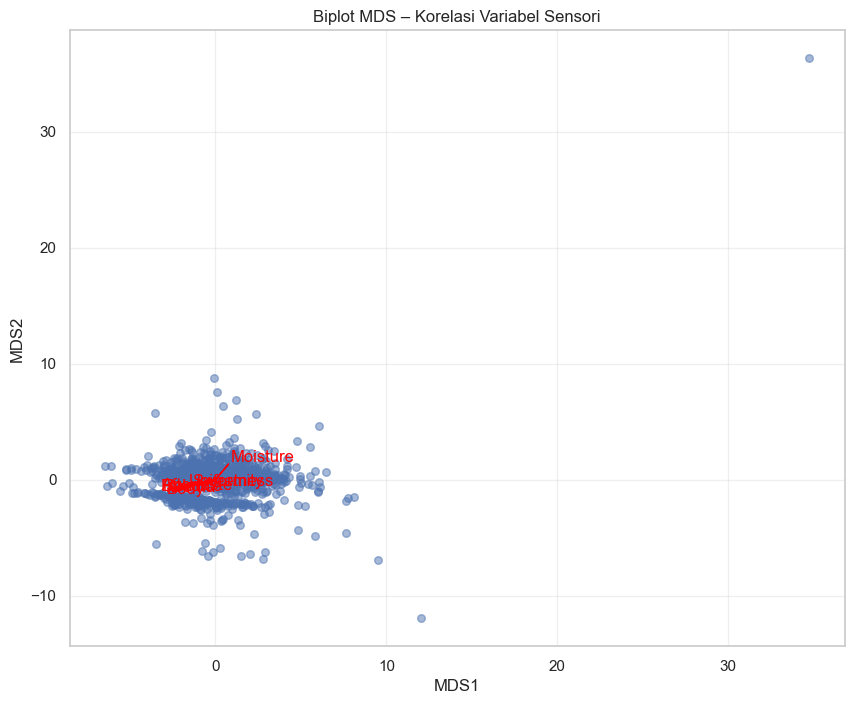

In [11]:
plt.figure(figsize=(10,8))
plt.scatter(coords[:,0], coords[:,1], alpha=0.5, s=30)

scale = 3
for var in selected_vars:
    x, y = corr_df.loc[var]
    plt.arrow(0,0, x*scale, y*scale, color="red", width=0.004)
    plt.text(x*scale*1.15, y*scale*1.15, var, color="red")

plt.title("Biplot MDS – Korelasi Variabel Sensori")
plt.xlabel("MDS1"); plt.ylabel("MDS2")
plt.grid(alpha=0.3)
plt.show()


## 8. Clustering pada Ruang MDS

In [12]:
sil_values = []
labels_list = []

for k in range(2,7):
    km = KMeans(n_clusters=k, random_state=42).fit(coords)
    labels = km.labels_
    sil = silhouette_score(coords, labels)
    sil_values.append(sil)
    labels_list.append(labels)
    print(f"k={k}, silhouette={sil:.4f}")

best_k = np.argmax(sil_values) + 2
best_labels = labels_list[np.argmax(sil_values)]

meta["cluster"] = best_labels
X["cluster"] = best_labels
best_k

k=2, silhouette=0.9426
k=3, silhouette=0.3411
k=4, silhouette=0.3536
k=5, silhouette=0.3850
k=6, silhouette=0.3908


np.int64(2)

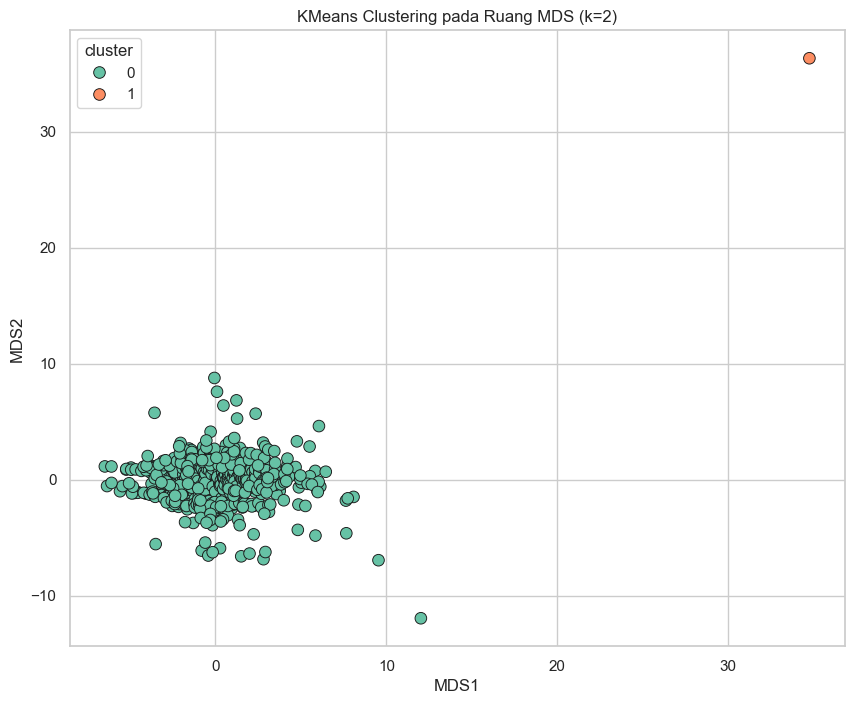

In [13]:
plt.figure(figsize=(10,8))
sns.scatterplot(
    x="MDS1", y="MDS2", hue="cluster",
    data=X, palette="Set2", s=70, edgecolor="k"
)
plt.title(f"KMeans Clustering pada Ruang MDS (k={best_k})")
plt.show()

## 9. Menambahkan Skor Kualitas (Total.Cup.Points)

In [14]:
X["score"] = df.loc[X.index, score_col].astype(float)
meta["score"] = X["score"]

X["score"].describe()

count    1311.000000
mean       82.115927
std         3.515761
min         0.000000
25%        81.170000
50%        82.500000
75%        83.670000
max        90.580000
Name: score, dtype: float64

## 10. Hubungan Skor Kualitas dengan MDS

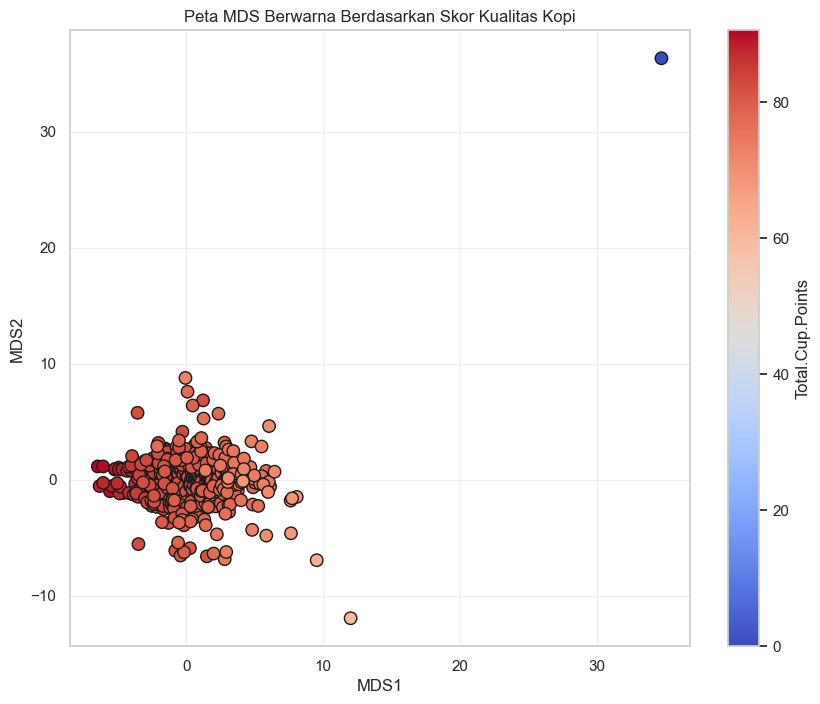

Corr(score, MDS1) = -0.9100172062856084
Corr(score, MDS2) = -0.30041190651635546


In [15]:
plt.figure(figsize=(10,8))
plt.scatter(
    X["MDS1"], X["MDS2"],
    c=X["score"], cmap="coolwarm",
    s=80, edgecolor="k"
)
plt.colorbar(label="Total.Cup.Points")
plt.title("Peta MDS Berwarna Berdasarkan Skor Kualitas Kopi")
plt.xlabel("MDS1"); plt.ylabel("MDS2")
plt.grid(alpha=0.3)
plt.show()

print("Corr(score, MDS1) =", np.corrcoef(X["score"], X["MDS1"])[0,1])
print("Corr(score, MDS2) =", np.corrcoef(X["score"], X["MDS2"])[0,1])

## 11. Perbedaan Skor Antar Klaster + ANOVA

C:\Users\Faiz Iqbal\AppData\Local\Temp\ipykernel_23072\2094092349.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=X["cluster"], y=X["score"], palette="Set2")


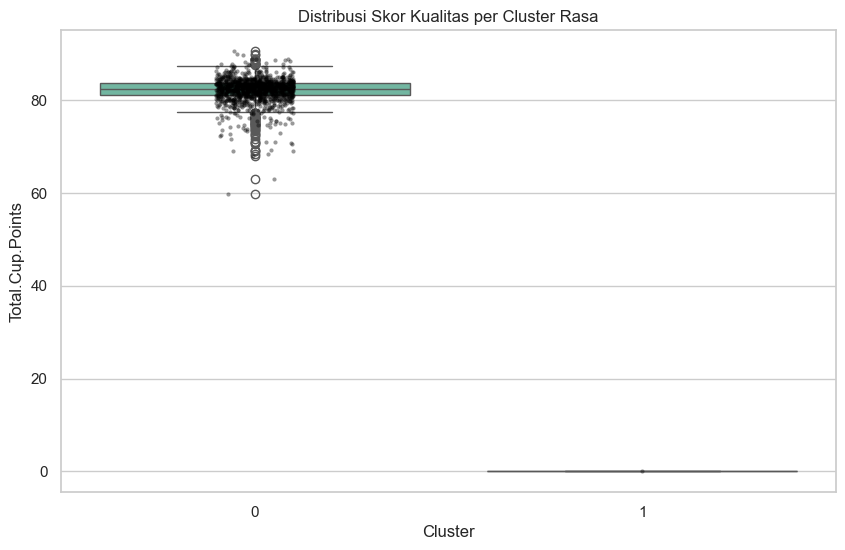

F_onewayResult(statistic=np.float64(935.3231270042047), pvalue=np.float64(1.9257553473326456e-155))

In [16]:
plt.figure(figsize=(10,6))
sns.boxplot(x=X["cluster"], y=X["score"], palette="Set2")
sns.stripplot(x=X["cluster"], y=X["score"], color="black", alpha=0.4, size=3)
plt.title("Distribusi Skor Kualitas per Cluster Rasa")
plt.xlabel("Cluster"); plt.ylabel("Total.Cup.Points")
plt.show()
groups = [X[X["cluster"]==c]["score"] for c in sorted(X["cluster"].unique())]
anova = stats.f_oneway(*groups)
anova


## Analisis Cluster dan MDS Lanjut

Data awal: 1310 baris
Data setelah outlier removal: 1310 baris

--- Statistika Deskriptif Data Agregat ---

Nilai Stress-1 (Kruskal): 0.0577


C:\Users\Faiz Iqbal\AppData\Roaming\Python\Python313\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


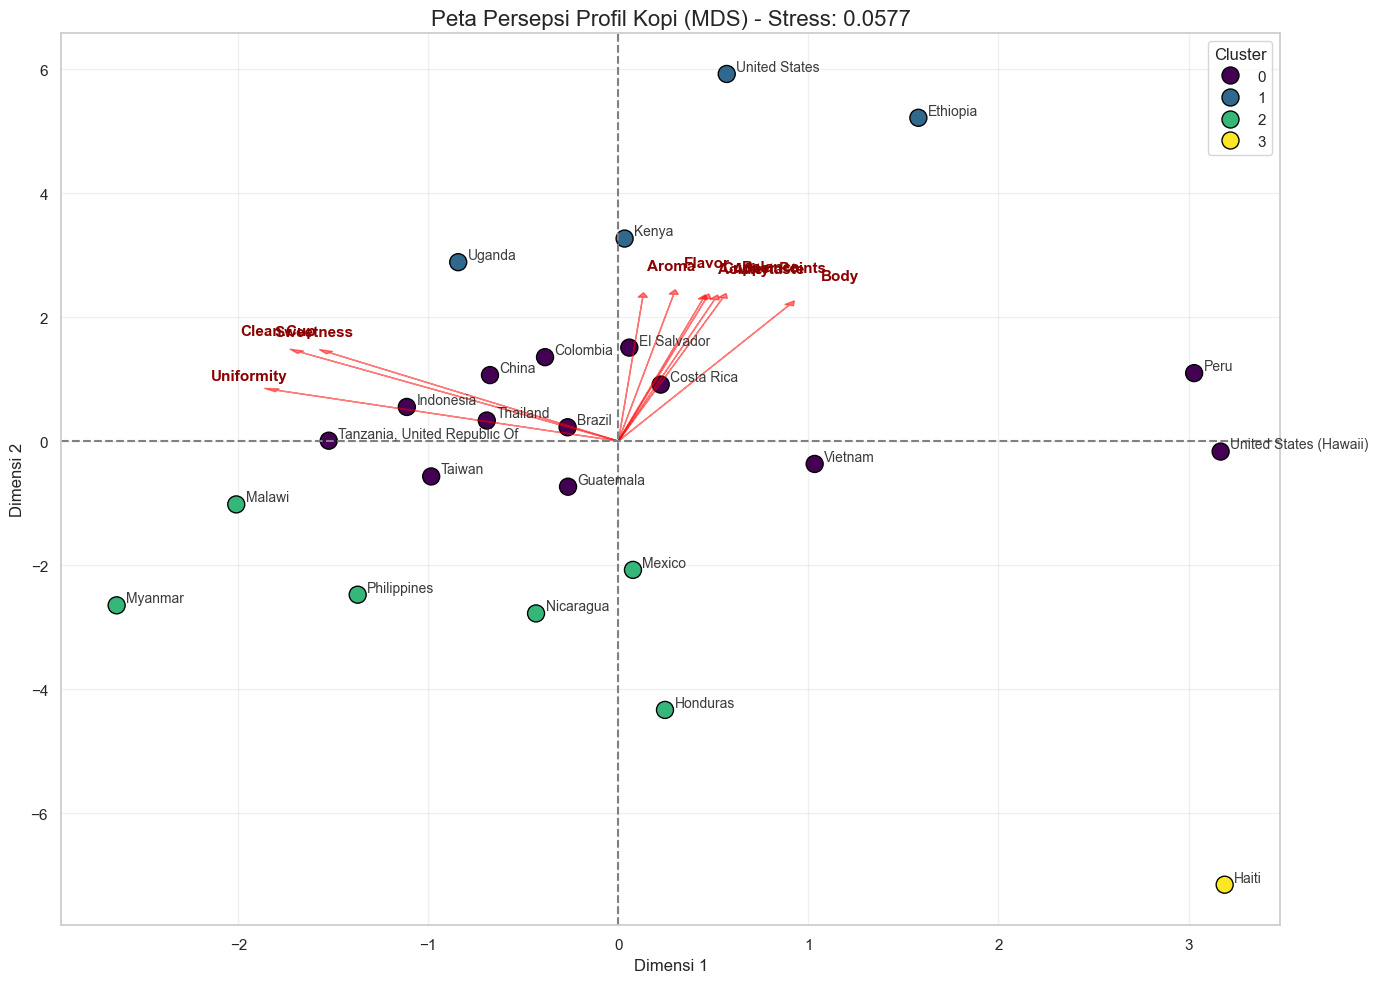


--- Profil Rata-rata per Cluster ---


,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Uniformity,Clean.Cup,Sweetness,Cupper.Points,Total.Cup.Points
Cluster,,,,,,,,,,,
1,7.868411,7.919628,7.799626,7.919789,7.819209,7.845235,9.962902,9.981880,9.959152,7.880964,84.956091
0,7.593764,7.552420,7.451415,7.551314,7.578426,7.569515,9.839399,9.875868,9.908746,7.559665,82.481477
2,7.385715,7.313645,7.195959,7.334817,7.321110,7.279446,9.842070,9.843775,9.886424,7.262294,80.666921
3,7.153333,6.998333,7.111667,7.126667,7.276667,7.056667,9.776667,8.555000,9.111667,7.013333,77.180000


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import mahalanobis
from scipy.stats import chi2
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import MDS
from sklearn.cluster import KMeans
from sklearn.metrics import euclidean_distances

df = pd.read_csv("C:/Uner/Semester 5/Multivariat/Coolyeah/Tugas Kelompok 5/dataset/arabica_data_cleaned.csv")

vars_sensori = ['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 
                'Balance', 'Uniformity', 'Clean.Cup', 'Sweetness', 'Cupper.Points']

vars_extra = ['Total.Cup.Points']
cols_to_keep = vars_sensori + vars_extra + ['Country.of.Origin']
df_analysis = df[cols_to_keep].dropna()

df_numeric = df_analysis[vars_sensori]
covariance = np.cov(df_numeric.values.T)
inv_covariance = np.linalg.inv(covariance)
mean_vals = np.mean(df_numeric.values, axis=0)

def calculate_mahalanobis(row, mean, inv_cov):
    return mahalanobis(row, mean, inv_cov)

df_analysis['mahalanobis'] = df_numeric.apply(
    lambda x: calculate_mahalanobis(x, mean_vals, inv_covariance), axis=1
)

p_val = 0.001
df_degrees = len(vars_sensori)
critical_val = chi2.ppf(1 - p_val, df_degrees)

df_clean = df_analysis[df_analysis['mahalanobis'] <= critical_val].copy()
print(f"Data awal: {len(df_analysis)} baris")
print(f"Data setelah outlier removal: {len(df_clean)} baris")

country_counts = df_clean['Country.of.Origin'].value_counts()
valid_countries = country_counts[country_counts >= 5].index

df_grouped = df_clean[df_clean['Country.of.Origin'].isin(valid_countries)]
df_grouped = df_grouped.groupby('Country.of.Origin')[vars_sensori + vars_extra].mean()

print("\n--- Statistika Deskriptif Data Agregat ---")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_grouped[vars_sensori])

mds = MDS(n_components=2, metric=True, dissimilarity='euclidean', random_state=42, normalized_stress='auto')
mds_coords = mds.fit_transform(X_scaled)

d_original = euclidean_distances(X_scaled)
stress_raw = mds.stress_
stress_1 = np.sqrt(stress_raw / (0.5 * np.sum(d_original**2)))

print(f"\nNilai Stress-1 (Kruskal): {stress_1:.4f}")

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
df_grouped['Cluster'] = clusters

plt.figure(figsize=(14, 10))
sns.scatterplot(x=mds_coords[:,0], y=mds_coords[:,1], 
                hue=df_grouped['Cluster'], palette='viridis', s=150, edgecolor='black')

for i, txt in enumerate(df_grouped.index):
    plt.annotate(txt, (mds_coords[i,0]+0.05, mds_coords[i,1]+0.05), fontsize=10, alpha=0.9)

correlations = []
for var in vars_sensori: 
    corr_x = np.corrcoef(df_grouped[var], mds_coords[:,0])[0,1]
    corr_y = np.corrcoef(df_grouped[var], mds_coords[:,1])[0,1]
    correlations.append((corr_x, corr_y))

scale_factor = 2.5
for i, (comp1, comp2) in enumerate(correlations):
    plt.arrow(0, 0, comp1*scale_factor, comp2*scale_factor, 
              color='red', alpha=0.5, head_width=0.05, length_includes_head=True)
    plt.text(comp1*scale_factor*1.15, comp2*scale_factor*1.15, 
             vars_sensori[i], color='darkred', fontsize=11, weight='bold')

plt.title(f'Peta Persepsi Profil Kopi (MDS) - Stress: {stress_1:.4f}', fontsize=16)
plt.xlabel('Dimensi 1', fontsize=12)
plt.ylabel('Dimensi 2', fontsize=12)
plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')
plt.grid(True, alpha=0.3)
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

print("\n--- Profil Rata-rata per Cluster ---")
display(df_grouped.groupby('Cluster').mean().sort_values('Total.Cup.Points', ascending=False))